In [1]:
root = "../../../Datasets/EEG Motor Movement/original/files"

In [2]:
import mne
import numpy as np
from pathlib import Path

# ----------------------------------------
# Load one EDF run
# ----------------------------------------
def load_physionet_run(edf_path):
    raw = mne.io.read_raw_edf(
        edf_path,
        preload=True,
        verbose=False
    )

    # Keep EEG only
    raw.pick_types(eeg=True)

    # --- Clean channel names ---
    new_names = {}
    for ch in raw.ch_names:
        clean = ch.strip(".")        # remove trailing dots
        clean = clean.capitalize()   # fix capitalization
        new_names[ch] = clean

    raw.rename_channels(new_names)

    # Now montage works
    raw.set_montage("standard_1020", on_missing="ignore", verbose=False)

    events, event_id = mne.events_from_annotations(raw)

    return raw, events, event_id


# ----------------------------------------
# Load selected runs of one subject
# ----------------------------------------
def load_physionet_subject(root_dir, subject_id, runs=[4,8,12]):
    """
    runs:
        4,8,12 -> left/right imagery
        6,10,14 -> both fists vs feet imagery
    """
    subject_str = f"S{subject_id:03d}"
    subject_path = Path(root_dir) / subject_str

    X_all = []
    y_all = []

    for run in runs:
        edf_file = subject_path / f"{subject_str}R{run:02d}.edf"

        raw, events, event_id = load_physionet_run(edf_file)

        # Select only T1 and T2
        mi_event_id = {
            k: v for k, v in event_id.items()
            if k in ["T1", "T2"]
        }

        epochs = mne.Epochs(
            raw,
            events,
            event_id=mi_event_id,
            tmin=0.0,
            tmax=4.0,
            baseline=None,
            preload=True,
            verbose=False
        )

        X = epochs.get_data()  # (trials, channels, samples)
        y = epochs.events[:, -1]

        # Map T1 -> 0, T2 -> 1
        code_map = {
            event_id["T1"]: 0,
            event_id["T2"]: 1
        }
        y = np.array([code_map[c] for c in y])

        X_all.append(X)
        y_all.append(y)

    X_all = np.concatenate(X_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)

    return X_all, y_all

In [3]:
X, y = load_physionet_subject(root, subject_id=1)
print(X.shape)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
(45, 64, 641)


In [4]:
raw, events, event_id = load_physionet_run(
    Path(root) / "S001" / "S001R04.edf"
)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


/Users/edsonodake/miniforge3/envs/svm_env/lib/python3.10/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


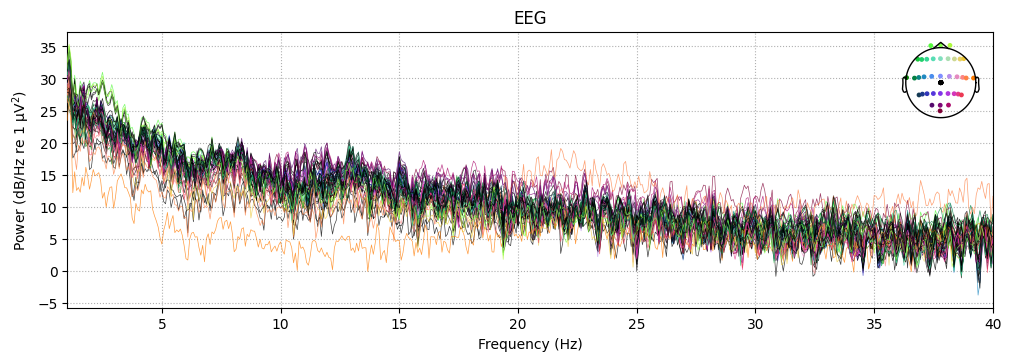

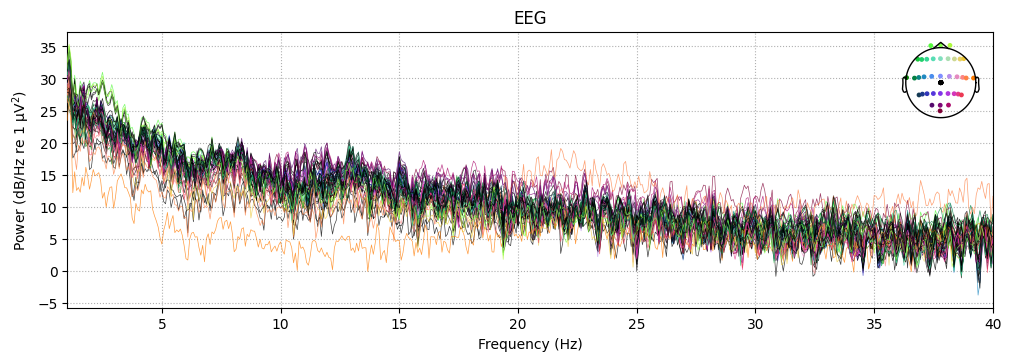

In [5]:
raw.plot_psd(fmin=1, fmax=40)

In [6]:
raw.filter(8., 30., fir_design="firwin")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [7]:
print(raw.ch_names)

['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4', 'Cp6', 'Fp1', 'Fpz', 'Fp2', 'Af7', 'Af3', 'Afz', 'Af4', 'Af8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'Ft7', 'Ft8', 'T7', 'T8', 'T9', 'T10', 'Tp7', 'Tp8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'Po7', 'Po3', 'Poz', 'Po4', 'Po8', 'O1', 'Oz', 'O2', 'Iz']
